# ANIME RECOMMENDER SYSTEM

## IMPORTS

In [1]:
!pip install matplotlib wordcloud

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.1/8.1 MB 37.7 MB/s  0:00:00m0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 37.4 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 43.9 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8/8 [wordcloud]/8 [matplotlib]


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import Activation, BatchNormalization, Input, Embedding, Dot, Dense, Flatten
from tensorflow.keras.callbacks import ModelCheckpoint, LearningRateScheduler, TensorBoard, EarlyStopping

from wordcloud import WordCloud
%matplotlib inline

### READING ANIMELIST.CSV

In [6]:
import os

In [7]:
INPUT_DIR = os.path.join('..', 'artifacts', 'raw')

In [8]:
rating_df = pd.read_csv(INPUT_DIR + '/animelist.csv', low_memory=True, usecols=['user_id', 'anime_id', 'rating'])

In [9]:
rating_df.head()

,user_id,anime_id,rating
0,0,67,9
1,0,6702,7
2,0,242,10
3,0,4898,0
4,0,21,10


In [10]:
len(rating_df)

5000000

#### DATA PROCESSING

In [12]:
n_ratings = rating_df['user_id'].value_counts()
n_ratings

user_id
11100    14429
10255     8403
4773      5735
6852      5406
16057     5080
         ...  
16363        1
16377        1
16450        1
16465        1
16480        1
Name: count, Length: 15186, dtype: int64

In [13]:
rating_df = rating_df[rating_df['user_id'].isin(n_ratings[n_ratings >= 400].index)].copy()

In [14]:
len(rating_df)

3246641

In [15]:
min_rating = min(rating_df['rating'])
min_rating

0

In [16]:
max_rating = max(rating_df['rating'])
max_rating

10

In [18]:
avg_rating = np.mean(rating_df['rating'])
avg_rating

np.float64(4.122732695114736)

In [19]:
rating_df['rating'] = rating_df['rating'].apply(lambda x: (x - min_rating) / (max_rating - min_rating)).values.astype('float')

In [21]:
avg_rating = np.mean(rating_df['rating'])
avg_rating

np.float64(0.4122732695114736)

In [25]:
min_rating = min(rating_df['rating'])
min_rating

0.0

In [24]:
max_rating = max(rating_df['rating'])
max_rating

1.0

In [28]:
rating_df.duplicated().any()

np.False_

In [29]:
rating_df.isnull().any()

user_id     False
anime_id    False
rating      False
dtype: bool

In [31]:
user_ids = rating_df['user_id'].unique().tolist()
user2user_encoded = {x: i for i, x in enumerate(user_ids)}

In [ ]:
user2user_decoded = {i: x for i, x in enumerate(user_ids)}
user2user_decoded

In [36]:
rating_df['user'] = rating_df['user_id'].map(user2user_encoded)
rating_df.head()

,user_id,anime_id,rating,user
213,2,24833,0.0,0
214,2,235,1.0,0
215,2,36721,0.0,0
216,2,40956,0.0,0
217,2,31933,0.0,0


In [37]:
n_users = len(user2user_encoded)
n_users

4203

In [43]:
anime_ids = rating_df['anime_id'].unique().tolist()
anime2anime_encoded = {x: i for i, x in enumerate(anime_ids)}
anime2anime_decoded = {i: x for i, x in enumerate(anime_ids)}
rating_df['anime'] = rating_df['anime_id'].map(anime2anime_encoded)

In [44]:
n_anime = len(anime2anime_encoded)
n_anime

17149

In [45]:
rating_df = rating_df.sample(frac=1, random_state=9).reset_index(drop=True)

In [47]:
X = rating_df[['user', 'anime']].values
y = rating_df['rating']

In [49]:
test_size = 1000
train_indices = rating_df.shape[0] - test_size

In [50]:
X_train, X_test, y_train, y_test = (
    X[:train_indices],
    X[train_indices:],
    y[:train_indices],
    y[train_indices:]
)

In [55]:
X_train_array = [X_train[:, 0], X_train[:, 1]]
X_test_array = [X_test[:, 0], X_test[:, 1]]

### MODEL ARCHITECTURE

In [59]:
def RecommenderNet():
    embedding_size = 128

    user = Input(name='user', shape=[1])

    user_embedding = Embedding(
        name='user_embedding',
        input_dim=n_users,
        output_dim=embedding_size
        )(user)
    
    anime = Input(name='anime', shape=[1])

    anime_embedding = Embedding(
        name='anime_embedding',
        input_dim=n_anime,
        output_dim=embedding_size
    )(anime)

    x = Dot(
        name='dot_product',
        normalize=True,
        axes=2
    )([user_embedding, anime_embedding])

    x = Flatten()(x)

    x = Dense(1, kernel_initializer='he_normal')(x)
    x = BatchNormalization()(x)
    x = Activation('sigmoid')(x)

    model = Model(inputs=[user, anime], outputs=x)
    model.compile(loss='binary_crossentropy', metrics=['mse', 'mae'], optimizer='Adam')

    return model

In [60]:
model = RecommenderNet()
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ user (InputLayer)   │ (None, 1)         │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ anime (InputLayer)  │ (None, 1)         │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ user_embedding      │ (None, 1, 128)    │    537,984 │ user[0][0]        │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ anime_embedding     │ (None, 1, 128)    │  2,195,072 │ anime[0][0]       │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dot_product (Dot)   │ (None, 1, 1)      │          0 │ user_embedding[0… │
│                     │                   │            │ anime_embedding[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 1)         │          0 │ dot_product[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 1)         │          2 │ flatten[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 1)         │          4 │ dense[0][0]       │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 1)         │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,733,062 (10.43 MB)

 Trainable params: 2,733,060 (10.43 MB)

 Non-trainable params: 2 (8.00 B)

In [61]:
start_lr = 0.00001
min_lr = 0.00001
max_lr = 0.00005
batch_size = 10000

ramup_epochs = 5
sustain_epochs = 0
exp_decay = 0.8

def lrfn(epoch):
    if epoch < ramup_epochs:
        return (max_lr - start_lr) / ramup_epochs + start_lr
    elif epoch > ramup_epochs + sustain_epochs:
        return max_lr
    else:
        return (max_lr - min_lr) * exp_decay ** (epoch - ramup_epochs - sustain_epochs) + min_lr

In [62]:
lr_callback = LearningRateScheduler(lambda epoch: lrfn(epoch), verbose=0)
checkpoint_filepath = './weights.weights.h5'

model_checkpoint = ModelCheckpoint(
    filepath=checkpoint_filepath,
    save_weights_only=True,
    monitor='val_loss',
    mode='min',
    save_best_only=True
)

early_stopping = EarlyStopping(
    patience=3,
    monitor='val_loss',
    mode='min',
    restore_best_weights=True
)

In [63]:
my_callbacks = [model_checkpoint, lr_callback, early_stopping]

In [64]:
history = model.fit(
    x=X_train_array,
    y=y_train,
    batch_size=batch_size,
    epochs=20,
    verbose=1,
    validation_data=(X_test_array, y_test),
    callbacks=my_callbacks
)

Epoch 1/20
325/325 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - loss: 0.6995 - mae: 0.3625 - mse: 0.1587 - val_loss: 0.6929 - val_mae: 0.3651 - val_mse: 0.1586 - learning_rate: 1.8000e-05
Epoch 2/20
325/325 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - loss: 0.6973 - mae: 0.3618 - mse: 0.1576 - val_loss: 0.6947 - val_mae: 0.3662 - val_mse: 0.1595 - learning_rate: 1.8000e-05
Epoch 3/20
325/325 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - loss: 0.6954 - mae: 0.3613 - mse: 0.1567 - val_loss: 0.6966 - val_mae: 0.3669 - val_mse: 0.1604 - learning_rate: 1.8000e-05
Epoch 4/20
325/325 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - loss: 0.6937 - mae: 0.3608 - mse: 0.1558 - val_loss: 0.6956 - val_mae: 0.3667 - val_mse: 0.1600 - learning_rate: 1.8000e-05


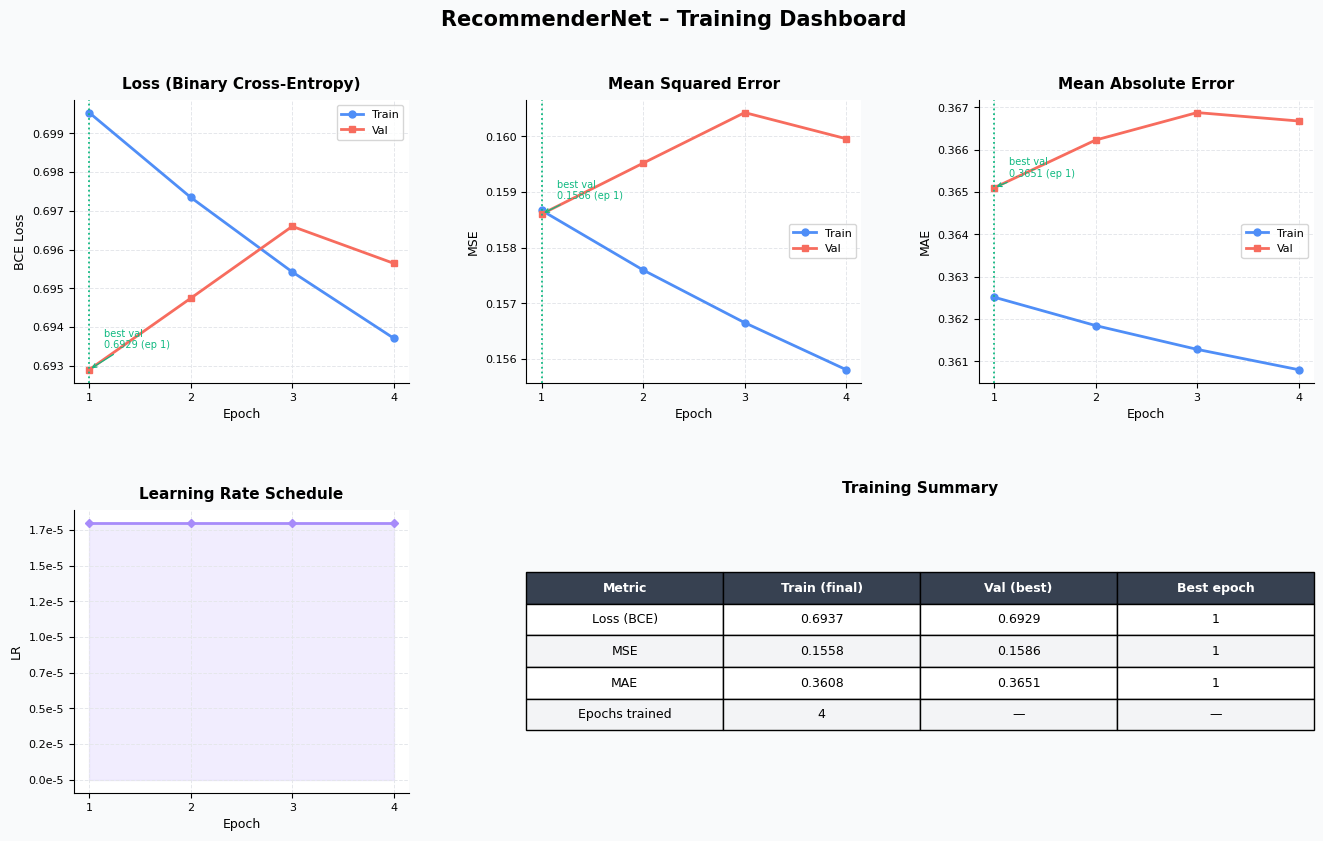

✓ Dashboard saved → training_dashboard.png  (4 epochs)


In [65]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.ticker import MaxNLocator

# ── Palette ────────────────────────────────────────────────────────────────
TRAIN_C = "#4F8EF7"
VAL_C   = "#F76C5E"
LR_C    = "#A78BFA"
ACCENT  = "#10B981"
GRID_C  = "#E5E7EB"
BG      = "#F9FAFB"

def _style(ax, title, ylabel):
    ax.set_facecolor("white")
    ax.set_title(title, fontsize=11, fontweight="bold", pad=8)
    ax.set_xlabel("Epoch", fontsize=9)
    ax.set_ylabel(ylabel, fontsize=9)
    ax.tick_params(labelsize=8)
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(color=GRID_C, linestyle="--", linewidth=0.7)
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))

def _plot_metric(ax, hist, train_key, val_key, title, ylabel):
    tv = hist[train_key]
    vv = hist[val_key]
    ep = range(1, len(tv) + 1)
    ax.plot(ep, tv, color=TRAIN_C, lw=2, marker="o", ms=5, label="Train")
    ax.plot(ep, vv, color=VAL_C,   lw=2, marker="s", ms=5, label="Val")
    best_e = vv.index(min(vv)) + 1
    best_v = min(vv)
    ax.axvline(best_e, color=ACCENT, lw=1.3, ls=":")
    ax.annotate(
        f"best val\n{best_v:.4f} (ep {best_e})",
        xy=(best_e, best_v),
        xytext=(best_e + 0.15, best_v + (max(vv)-min(vv)) * 0.15 + 1e-6),
        fontsize=7, color=ACCENT,
        arrowprops=dict(arrowstyle="->", color=ACCENT, lw=0.9),
    )
    ax.legend(fontsize=8)
    _style(ax, title, ylabel)

def _plot_lr(ax, n_epochs):
    ep  = list(range(1, n_epochs + 1))
    lrs = [lrfn(e - 1) for e in ep]          # reuse lrfn already defined above
    ax.fill_between(ep, lrs, alpha=0.15, color=LR_C)
    ax.plot(ep, lrs, color=LR_C, lw=2, marker="D", ms=4)
    ax.yaxis.set_major_formatter(
        plt.FuncFormatter(lambda v, _: f"{v*1e5:.1f}e-5"))
    _style(ax, "Learning Rate Schedule", "LR")

def _summary(ax, hist):
    ax.axis("off")
    n = len(hist["loss"])
    rows = [
        ["Metric",      "Train (final)", "Val (best)",           "Best epoch"],
        ["Loss (BCE)",  f"{hist['loss'][-1]:.4f}",
                        f"{min(hist['val_loss']):.4f}",
                        str(hist['val_loss'].index(min(hist['val_loss']))+1)],
        ["MSE",         f"{hist['mse'][-1]:.4f}",
                        f"{min(hist['val_mse']):.4f}",
                        str(hist['val_mse'].index(min(hist['val_mse']))+1)],
        ["MAE",         f"{hist['mae'][-1]:.4f}",
                        f"{min(hist['val_mae']):.4f}",
                        str(hist['val_mae'].index(min(hist['val_mae']))+1)],
        ["Epochs trained", str(n), "—", "—"],
    ]
    t = ax.table(cellText=rows[1:], colLabels=rows[0],
                 loc="center", cellLoc="center")
    t.auto_set_font_size(False); t.set_fontsize(9); t.scale(1, 1.9)
    for j in range(4):
        t[0, j].set_facecolor("#374151")
        t[0, j].set_text_props(color="white", fontweight="bold")
    for i in range(1, len(rows)):
        bg = "#F3F4F6" if i % 2 == 0 else "white"
        for j in range(4): t[i, j].set_facecolor(bg)
    ax.set_title("Training Summary", fontsize=11, fontweight="bold", pad=12)

# ── Build figure ───────────────────────────────────────────────────────────
hist  = history.history
n_ep  = len(hist["loss"])

fig = plt.figure(figsize=(16, 9), facecolor=BG)
fig.suptitle("RecommenderNet – Training Dashboard",
             fontsize=15, fontweight="bold", y=0.98)

gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

_plot_metric(fig.add_subplot(gs[0, 0]), hist, "loss",  "val_loss",
             "Loss (Binary Cross-Entropy)", "BCE Loss")
_plot_metric(fig.add_subplot(gs[0, 1]), hist, "mse",   "val_mse",
             "Mean Squared Error", "MSE")
_plot_metric(fig.add_subplot(gs[0, 2]), hist, "mae",   "val_mae",
             "Mean Absolute Error", "MAE")
_plot_lr(fig.add_subplot(gs[1, 0]), n_ep)
_summary(fig.add_subplot(gs[1, 1:]), hist)

plt.savefig("training_dashboard.png", dpi=150, bbox_inches="tight", facecolor=BG)
plt.show()
print(f"✓ Dashboard saved → training_dashboard.png  ({n_ep} epochs)")


In [66]:
def extract_weights(name, model):
    weight_layer = model.get_layer(name)
    weights = weight_layer.get_weights()[0]
    weights = weights / np.linalg.norm(weights, axis=1).reshape(-1, 1)
    return weights

In [67]:
anime_weights = extract_weights('anime_embedding', model)

In [68]:
user_weights= extract_weights('user_embedding', model)

### READING ANIME.CSV

In [69]:
df = pd.read_csv(INPUT_DIR + '/anime.csv', low_memory=True)
df.head(2)

,MAL_ID,Name,Score,Genres,English name,Japanese name,Type,Episodes,Aired,Premiered,...,Score-10,Score-9,Score-8,Score-7,Score-6,Score-5,Score-4,Score-3,Score-2,Score-1
0,1,Cowboy Bebop,8.78,"Action, Adventure, Comedy, Drama, Sci-Fi, Space",Cowboy Bebop,カウボーイビバップ,TV,26,"Apr 3, 1998 to Apr 24, 1999",Spring 1998,...,229170.0,182126.0,131625.0,62330.0,20688.0,8904.0,3184.0,1357.0,741.0,1580.0
1,5,Cowboy Bebop: Tengoku no Tobira,8.39,"Action, Drama, Mystery, Sci-Fi, Space",Cowboy Bebop:The Movie,カウボーイビバップ 天国の扉,Movie,1,"Sep 1, 2001",Unknown,...,30043.0,49201.0,49505.0,22632.0,5805.0,1877.0,577.0,221.0,109.0,379.0


In [70]:
df = df.replace('Unknown', np.nan)

In [79]:
def getAnimeName(anime_id):
    try:
        name = df[df['anime_id'] == anime_id]['eng_version'].values[0]
        if name is np.nan:
            name = df[df['anime_id'] == anime_id]['Name'].values[0]
    except:
        print('Error')
    return name

In [80]:
df['anime_id'] = df['MAL_ID']
df['eng_version'] = df['English name']
df['eng_version'] = df['anime_id'].apply(lambda x: getAnimeName(x))

In [81]:
df.head(1)

,MAL_ID,Name,Score,Genres,English name,Japanese name,Type,Episodes,Aired,Premiered,...,Score-8,Score-7,Score-6,Score-5,Score-4,Score-3,Score-2,Score-1,anime_id,eng_version
0,1,Cowboy Bebop,8.78,"Action, Adventure, Comedy, Drama, Sci-Fi, Space",Cowboy Bebop,カウボーイビバップ,TV,26,"Apr 3, 1998 to Apr 24, 1999",Spring 1998,...,131625.0,62330.0,20688.0,8904.0,3184.0,1357.0,741.0,1580.0,1,Cowboy Bebop


In [93]:
df.sort_values(
    by=['Score'],
    ascending=False,
    kind='quicksort',
    na_position='last',
    inplace=True
)

In [94]:
df.columns

Index(['anime_id', 'eng_version', 'Score', 'Genres', 'Episodes', 'Type',
       'Premiered', 'Members'],
      dtype='str')

In [95]:
df = df[['anime_id', 'eng_version', 'Score', 'Genres', 'Episodes', 'Type', 'Premiered', 'Members']]

In [96]:
df

,anime_id,eng_version,Score,Genres,Episodes,Type,Premiered,Members
3971,5114,Fullmetal Alchemist:Brotherhood,9.19,"Action, Military, Adventure, Comedy, Drama, Ma...",64,TV,Spring 2009,2248456
15926,40028,Attack on Titan Final Season,9.17,"Action, Military, Mystery, Super Power, Drama,...",16,TV,Winter 2021,733260
5683,9253,Steins;Gate,9.11,"Thriller, Sci-Fi",24,TV,Spring 2011,1771162
14963,38524,Attack on Titan Season 3 Part 2,9.1,"Action, Drama, Fantasy, Military, Mystery, Sho...",10,TV,Spring 2019,1073626
9913,28977,Gintama Season 4,9.1,"Action, Comedy, Historical, Parody, Samurai, S...",51,TV,Spring 2015,404121
...,...,...,...,...,...,...,...,...
17557,48481,Daomu Biji Zhi Qinling Shen Shu,NaN,"Adventure, Mystery, Supernatural",NaN,ONA,NaN,354
17558,48483,Mieruko-chan,NaN,"Comedy, Horror, Supernatural",NaN,TV,NaN,7010
17559,48488,Higurashi:When They Cry – SOTSU,NaN,"Mystery, Dementia, Horror, Psychological, Supe...",NaN,TV,Summer 2021,11309
17560,48491,Yama no Susume: Next Summit,NaN,"Adventure, Slice of Life, Comedy",NaN,TV,NaN,1386


In [97]:
def getAnimeFrame(anime, df):
    if isinstance(anime, int):
        return df[df['anime_id'] == anime]
    return df[df['eng_version'] == anime]

In [99]:
getAnimeFrame(6418, df)

,anime_id,eng_version,Score,Genres,Episodes,Type,Premiered,Members
4587,6418,Eyeshield 21: Jump Festa 2005 Special,6.77,"Action, Comedy, Shounen, Sports",1,Special,NaN,5831


In [104]:
getAnimeFrame('Naruto', df)

,anime_id,eng_version,Score,Genres,Episodes,Type,Premiered,Members
10,20,Naruto,7.91,"Action, Adventure, Comedy, Super Power, Martia...",220,TV,Fall 2002,1830540


### ANIME_WITH_SYPNOPSIS.CSV

In [108]:
cols = ['MAL_ID', 'Name', 'Genres', 'sypnopsis']

In [109]:
synopsis_df = pd.read_csv(INPUT_DIR + '/anime_with_synopsis.csv', usecols=cols)

In [110]:
synopsis_df.head(1)

,MAL_ID,Name,Genres,sypnopsis
0,1,Cowboy Bebop,"Action, Adventure, Comedy, Drama, Sci-Fi, Space","In the year 2071, humanity has colonized sever..."


In [116]:
def getSynopsis(anime, df):
    if isinstance(anime, int):
        return df[df['MAL_ID'] == anime]['sypnopsis'].values[0]
    return df[df['Name'] == anime]['sypnopsis'].values[0]

In [117]:
getSynopsis('Naruto', synopsis_df)

"oments prior to Naruto Uzumaki's birth, a huge demon known as the Kyuubi, the Nine-Tailed Fox, attacked Konohagakure, the Hidden Leaf Village, and wreaked havoc. In order to put an end to the Kyuubi's rampage, the leader of the village, the Fourth Hokage, sacrificed his life and sealed the monstrous beast inside the newborn Naruto. Now, Naruto is a hyperactive and knuckle-headed ninja still living in Konohagakure. Shunned because of the Kyuubi inside him, Naruto struggles to find his place in the village, while his burning desire to become the Hokage of Konohagakure leads him not only to some great new friends, but also some deadly foes."

In [120]:
getSynopsis(15, synopsis_df)

'Sena is like any other shy kid starting high school; he\'s just trying to survive. Constantly bullied, he\'s accustomed to running away. Surviving high school is about to become a lot more difficult after Hiruma, captain of the school\'s American football team, witnesses Sena\'s incredible agility and speed during an escape from some bullies. Hiruma schemes to make Sena the running back of his school team, The Devil Bats, hoping that it will turn around the squad\'s fortunes from being the laughingstock of Japan\'s high school leagues, to title contender. To protect his precious star player from rivaling recruiters, he enlists Sena as "team secretary," giving him a visored helmet and the nickname "Eyeshield 21" to hide his identity. The Devilbats will look to make their way to the Christmas Bowl, an annual tournament attended by the best football teams in Japan, with "Eyeshield 21" leading the way. Will they be able to win the Christmas Bowl? Will Sena be able to transform from a timi

### CONTENT/ITEM BASED RECOMMENDATION

In [122]:
pd.set_option('max_colwidth', None)

In [141]:
def find_similar_animes(name, anime_weights, anime2anime_encoded, anime2anime_decoded, df, synopsis_df, n=10, return_dist=False, neg=False):
    # Get the anime_id for the given name
    index = getAnimeFrame(name, df).anime_id.values[0]
    encoded_index = anime2anime_encoded.get(index)

    if encoded_index is None:
        raise ValueError(f"Encoded index not found for anime ID: {index}")

    weights = anime_weights

    # Compute the similarity distances
    dists = np.dot(weights, weights[encoded_index])  # Ensure weights[encoded_index] is a 1D array
    sorted_dists = np.argsort(dists)

    n = n + 1

    # Select closest or farthest based on 'neg' flag
    if neg:
        closest = sorted_dists[:n]
    else:
        closest = sorted_dists[-n:]

    # Return distances and closest indices if requested
    if return_dist:
        return dists, closest

    # Build the similarity array
    SimilarityArr = []
    for close in closest:
        decoded_id = anime2anime_decoded.get(close)
       

       
        anime_frame = getAnimeFrame(decoded_id, df)

        anime_name = anime_frame.eng_version.values[0]
        genre = anime_frame.Genres.values[0]
        similarity = dists[close]
   

        SimilarityArr.append({
            "anime_id": decoded_id,
            "name": anime_name,
            "similarity": similarity,
            "genre": genre,
        })
       

    # Create a DataFrame with results and sort by similarity
    Frame = pd.DataFrame(SimilarityArr).sort_values(by="similarity", ascending=False)
    return Frame[Frame.anime_id != index].drop(['anime_id'], axis=1)


In [142]:
find_similar_animes('Dragon Ball', anime_weights, anime2anime_encoded, anime2anime_decoded,
                    df, synopsis_df)

,name,similarity,genre
9,Hunter x Hunter Movie 2: The Last Mission,0.352651,"Action, Adventure, Super Power, Fantasy, Shounen"
8,Gintama: Nanigoto mo Saiyo ga Kanjin nano de Tasho Senobisuru Kurai ga Choudoyoi,0.345097,"Action, Sci-Fi, Comedy, Historical, Parody, Samurai, Mecha, Shounen"
7,Armed Librarians:The Book of Bantorra,0.304858,"Action, Fantasy, Seinen, Super Power"
6,Recorder,0.304688,"Dementia, Music"
5,Air Gear:Special Trick,0.302444,"Sports, Shounen"
4,"Rinkan Gakuen: Yamete! ...Okaasan, Minaide!",0.299174,Hentai
3,Chogattai Majutsu Robot Ginguiser,0.296785,"Adventure, Mecha, Sci-Fi, Shounen"
2,Senki Zesshou Symphogear G: Senki Zesshou Shinai Symphogear,0.294961,"Slice of Life, Comedy"
1,Sexorcist,0.294863,Hentai
0,Pokemon XY&Z: Subete no Nazo wo Tokiakase!,0.293591,"Action, Adventure, Fantasy, Kids"
